# PathMNIST Dataset Exploration and Baseline Recall

This notebook has a narrower goal than the full improvement notebook:

1. Explore the PathMNIST dataset and class distribution.
2. Reproduce a simple benchmark-style baseline setup.
3. Report recall, especially cancer-class recall, so we have a rough baseline for comparison.

Important note: the official MedMNIST benchmark table reports AUC and accuracy, but not recall. Therefore, recall must be estimated by rerunning a comparable baseline and calculating per-class recall from predictions.

The local artifact used below is `cifar_resnet18_official_seed31`, an official-style 28x28 ResNet-18 run that was stopped early because it was slow on Apple MPS. Treat it as a rough baseline recall estimate, not as the final official benchmark reproduction.

## 1. Setup

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
RESULTS = ROOT / 'results'
DATA = ROOT / 'data'

CLASS_NAMES = [
    'adipose',
    'background',
    'debris',
    'lymphocytes',
    'mucus',
    'smooth muscle',
    'normal colon mucosa',
    'cancer-associated stroma',
    'colorectal adenocarcinoma epithelium',
]

plt.style.use('seaborn-v0_8-whitegrid')

print('Project root:', ROOT)
print('Results exist:', RESULTS.exists())
print('Data exists:', DATA.exists())

Project root: /Users/nick/Workspace/pathmnist-classification-improvement
Results exist: True
Data exists: True


## 2. Official Benchmark Target

The README lists these official MedMNIST PathMNIST baselines:

| Method | Input size | AUC | ACC |
| --- | ---: | ---: | ---: |
| ResNet-18 | 28x28 | 0.983 | 0.907 |
| ResNet-18 | 224x224 | 0.989 | 0.909 |
| ResNet-50 | 28x28 | 0.990 | 0.911 |
| ResNet-50 | 224x224 | 0.989 | 0.892 |

The strongest listed 28x28 benchmark is ResNet-50 with:

- AUC: `0.990`
- ACC: `0.911`

But recall is missing, so this notebook computes recall from locally generated predictions.

In [2]:
benchmark = pd.DataFrame([
    {'method': 'ResNet-18', 'input_size': '28x28', 'auc': 0.983, 'acc': 0.907},
    {'method': 'ResNet-18', 'input_size': '224x224', 'auc': 0.989, 'acc': 0.909},
    {'method': 'ResNet-50', 'input_size': '28x28', 'auc': 0.990, 'acc': 0.911},
    {'method': 'ResNet-50', 'input_size': '224x224', 'auc': 0.989, 'acc': 0.892},
])
display(benchmark)

,method,input_size,auc,acc
0,ResNet-18,28x28,0.983,0.907
1,ResNet-18,224x224,0.989,0.909
2,ResNet-50,28x28,0.990,0.911
3,ResNet-50,224x224,0.989,0.892


### Benchmark Metric Visualization

This bar chart makes the website benchmark differences easier to compare. The strongest listed 28x28 target is ResNet-50 with AUC `0.990` and ACC `0.911`.

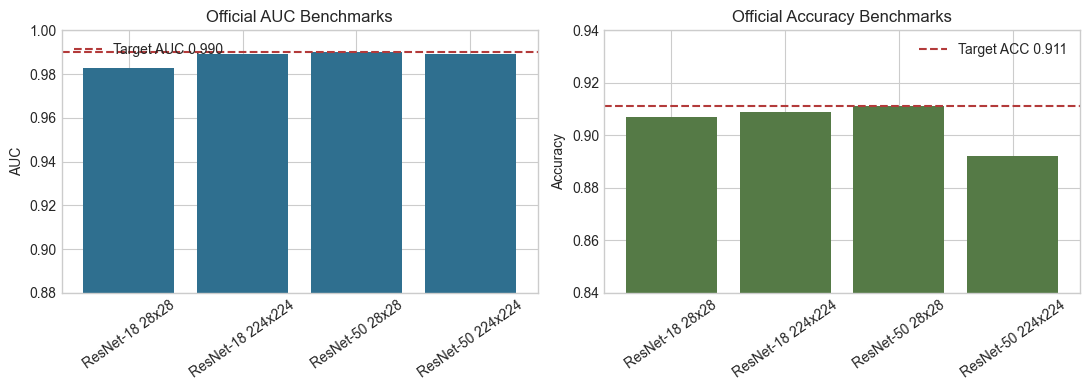

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
plot_df = benchmark.copy()
plot_df['label'] = plot_df['method'] + ' ' + plot_df['input_size']

axes[0].bar(plot_df['label'], plot_df['auc'], color='#2f6f8f')
axes[0].axhline(0.990, color='#b33a3a', linestyle='--', linewidth=1.5, label='Target AUC 0.990')
axes[0].set_title('Official AUC Benchmarks')
axes[0].set_ylabel('AUC')
axes[0].set_ylim(0.88, 1.0)
axes[0].tick_params(axis='x', rotation=35)
axes[0].legend()

axes[1].bar(plot_df['label'], plot_df['acc'], color='#557a46')
axes[1].axhline(0.911, color='#b33a3a', linestyle='--', linewidth=1.5, label='Target ACC 0.911')
axes[1].set_title('Official Accuracy Benchmarks')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.84, 0.94)
axes[1].tick_params(axis='x', rotation=35)
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Dataset Class Distribution

The test split comes from a different clinical center than train/validation, so checking class counts matters. Recall is class-sensitive and can reveal failures that accuracy hides.

In [4]:
dataset_summary_path = RESULTS / 'dataset_summary.json'

if dataset_summary_path.exists():
    dataset_summary = json.loads(dataset_summary_path.read_text())
else:
    dataset_summary = None
    print('No dataset_summary.json found. Run from project root:')
    print('.venv/bin/python scripts/analyze_dataset.py')

dataset_summary is not None

True

In [5]:
if dataset_summary:
    rows = []
    for split, info in dataset_summary['splits'].items():
        total = info['n']
        for class_name, count in info['counts'].items():
            rows.append({
                'split': split,
                'class': class_name,
                'count': count,
                'fraction': count / total,
            })
    counts = pd.DataFrame(rows)
    display(counts.pivot(index='class', columns='split', values='count'))
    display(counts.pivot(index='class', columns='split', values='fraction').round(3))

split,test,train,val
class,,,
adipose,1338,9366,1041
background,847,9509,1057
cancer-associated stroma,421,9401,1045
colorectal adenocarcinoma epithelium,1233,12885,1432
debris,339,10360,1152
lymphocytes,634,10401,1156
mucus,1035,8006,890
normal colon mucosa,741,7886,877
smooth muscle,592,12182,1354


split,test,train,val
class,,,
adipose,0.186,0.104,0.104
background,0.118,0.106,0.106
cancer-associated stroma,0.059,0.104,0.104
colorectal adenocarcinoma epithelium,0.172,0.143,0.143
debris,0.047,0.115,0.115
lymphocytes,0.088,0.116,0.116
mucus,0.144,0.089,0.089
normal colon mucosa,0.103,0.088,0.088
smooth muscle,0.082,0.135,0.135


### Class Distribution Visualizations

The first chart shows absolute sample counts. The second chart shows split-normalized fractions, which makes the train/validation/test distribution shift easier to see.

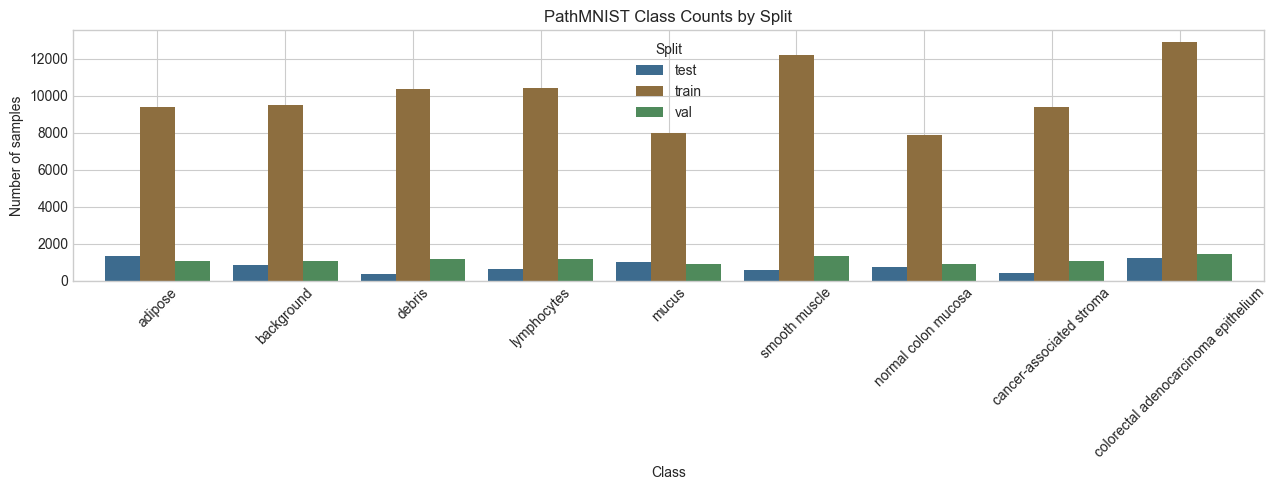

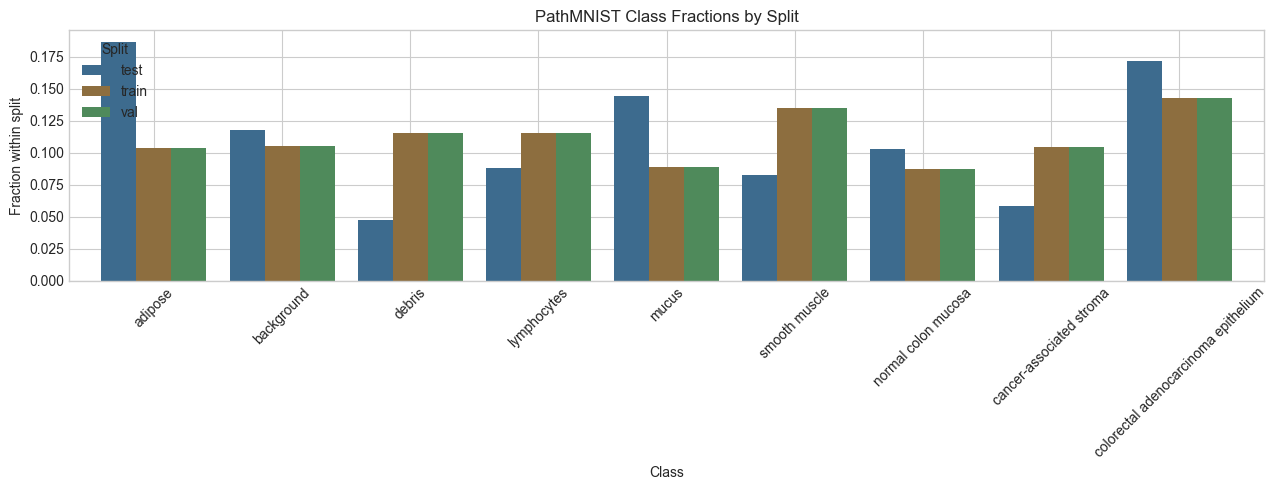

In [6]:
if dataset_summary:
    count_pivot = counts.pivot(index='class', columns='split', values='count').loc[CLASS_NAMES]
    ax = count_pivot.plot(kind='bar', figsize=(13, 5), width=0.82, color=['#3d6b8e', '#8d6e3f', '#4f8a5b'])
    ax.set_title('PathMNIST Class Counts by Split')
    ax.set_xlabel('Class')
    ax.set_ylabel('Number of samples')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Split')
    plt.tight_layout()
    plt.show()

    frac_pivot = counts.pivot(index='class', columns='split', values='fraction').loc[count_pivot.index]
    ax = frac_pivot.plot(kind='bar', figsize=(13, 5), width=0.82, color=['#3d6b8e', '#8d6e3f', '#4f8a5b'])
    ax.set_title('PathMNIST Class Fractions by Split')
    ax.set_xlabel('Class')
    ax.set_ylabel('Fraction within split')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Split')
    plt.tight_layout()
    plt.show()

## 4. Dataset Attributes

PathMNIST is not a tabular medical dataset. Each sample consists of an RGB image patch and one integer class label. The dataset-level metadata describes the task, class names, channels, split sizes, license, URLs, and checksums, but there are no extra per-image attributes such as patient ID, slide ID, age, sex, scanner, hospital, or disease history.

The next cells inspect both the MedMNIST dataset object and the raw `.npz` file to verify that.

In [7]:
from medmnist import PathMNIST, INFO

attribute_dataset = PathMNIST(split='train', download=False, size=28, root=str(DATA))

object_rows = []
for name, value in vars(attribute_dataset).items():
    if name.startswith('_'):
        continue
    if hasattr(value, 'shape'):
        object_rows.append({
            'attribute': name,
            'type': type(value).__name__,
            'shape': tuple(value.shape),
            'dtype_or_value': str(getattr(value, 'dtype', '')),
        })
    elif name == 'info':
        object_rows.append({
            'attribute': name,
            'type': type(value).__name__,
            'shape': '',
            'dtype_or_value': f"metadata keys: {', '.join(sorted(value.keys()))}",
        })
    else:
        object_rows.append({
            'attribute': name,
            'type': type(value).__name__,
            'shape': '',
            'dtype_or_value': repr(value),
        })

object_attributes = pd.DataFrame(object_rows)
display(object_attributes)

,attribute,type,shape,dtype_or_value
0,size,int,,28
1,size_flag,str,,''
2,info,dict,,"metadata keys: MD5, MD5_128, MD5_224, MD5_64, ..."
3,root,str,,'/Users/nick/Workspace/pathmnist-classificatio...
4,split,str,,'train'
5,transform,NoneType,,None
6,target_transform,NoneType,,None
7,as_rgb,bool,,False
8,imgs,ndarray,"(89996, 28, 28, 3)",uint8
9,labels,ndarray,"(89996, 1)",uint8


In [8]:
npz_path = DATA / 'pathmnist.npz'
if npz_path.exists():
    raw = np.load(npz_path)
    npz_attributes = pd.DataFrame([
        {
            'array_name': key,
            'shape': raw[key].shape,
            'dtype': raw[key].dtype,
            'meaning': 'image array' if key.endswith('_images') else 'single class label',
        }
        for key in raw.files
    ])
    display(npz_attributes)
else:
    print('Raw PathMNIST npz file not found:', npz_path)

,array_name,shape,dtype,meaning
0,train_images,"(89996, 28, 28, 3)",uint8,image array
1,val_images,"(10004, 28, 28, 3)",uint8,image array
2,test_images,"(7180, 28, 28, 3)",uint8,image array
3,train_labels,"(89996, 1)",uint8,single class label
4,val_labels,"(10004, 1)",uint8,single class label
5,test_labels,"(7180, 1)",uint8,single class label


### Attribute Interpretation

For modeling, the only per-sample inputs are the image pixels, and the only per-sample target is the class label.

This means the current task is:

- input: one RGB tissue patch, usually shaped `28 x 28 x 3` for the basic benchmark;
- target: one integer label from `0` to `8`;
- no additional structured attributes are available per image.

So if we want to improve performance, we cannot use patient-level or slide-level metadata directly. Improvements must come from image modeling, augmentation, resolution, ensembling, or derived features computed from the image itself.

## 5. Dataset Image Samples

The histogram tells us how many examples each class has, but it does not show what the model actually sees. The next cell samples raw 28x28 PathMNIST images from the training split and displays a few examples per class.

These are tiny RGB tissue patches. Some classes are visually clear, while others are subtle or mixed-looking, which helps explain why recall differs strongly by class.

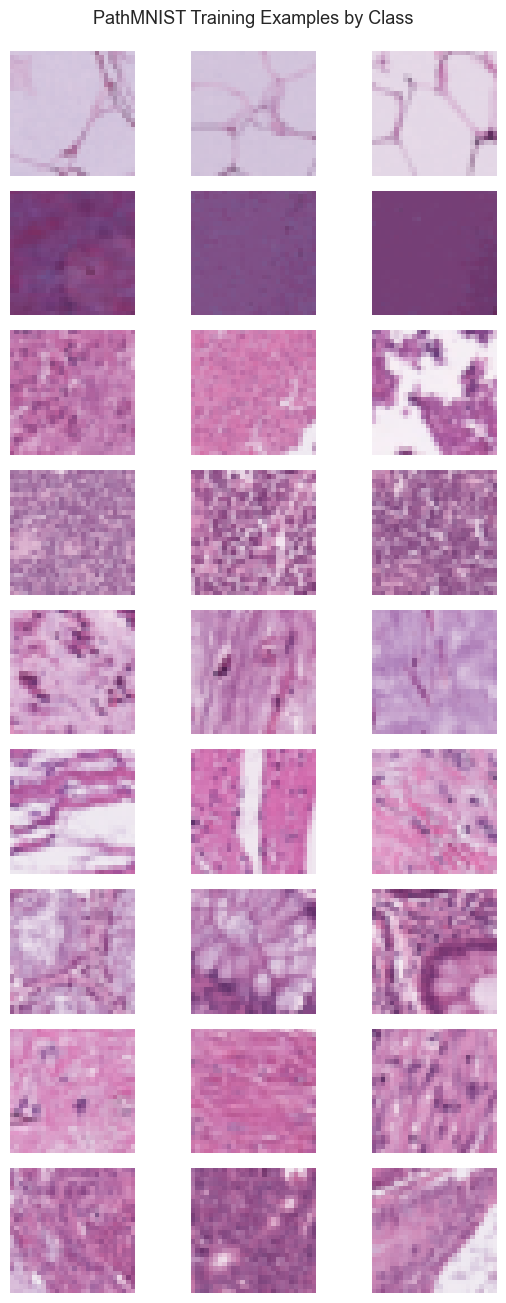

In [9]:
try:
    from medmnist import PathMNIST
except ImportError as exc:
    raise ImportError(
        'medmnist is required for this cell. Install project dependencies with: .venv/bin/python -m pip install -e .'
    ) from exc

sample_dataset = PathMNIST(split='train', download=False, size=28, root=str(DATA))
images = sample_dataset.imgs
labels = sample_dataset.labels.reshape(-1).astype(int)

examples_per_class = 3
rng = np.random.default_rng(7)
fig, axes = plt.subplots(len(CLASS_NAMES), examples_per_class, figsize=(examples_per_class * 2.0, len(CLASS_NAMES) * 1.45))

for class_idx, class_name in enumerate(CLASS_NAMES):
    class_indices = np.flatnonzero(labels == class_idx)
    chosen = rng.choice(class_indices, size=examples_per_class, replace=False)
    for col, img_idx in enumerate(chosen):
        ax = axes[class_idx, col]
        ax.imshow(images[img_idx])
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(class_name, rotation=0, ha='right', va='center', labelpad=58, fontsize=9)

fig.suptitle('PathMNIST Training Examples by Class', y=0.995, fontsize=13)
plt.tight_layout()
plt.show()

### Image Sample Notes

The images are low-resolution patches, not full-slide scans. This makes some distinctions hard by eye, especially between debris, smooth muscle, cancer-associated stroma, and adenocarcinoma-adjacent structures. That visual ambiguity is consistent with the recall failures seen later in the baseline confusion matrix.

### Observation

The test distribution differs from train/validation. In particular, some classes such as cancer-associated stroma and debris are relatively small in the test set. This makes per-class recall important because a model can have good overall accuracy while failing on a minority class.

## 6. Baseline Replication Strategy

The goal here is not to use the improved ensemble. The goal is to estimate baseline recall for a benchmark-like model.

For 28x28 PathMNIST, the official experiment style is closer to a CIFAR-style ResNet than a standard ImageNet ResNet because 28x28 images are small. The project code therefore includes:

- `cifar_resnet18`
- `cifar_resnet50`
- `--norm official`, which uses `Normalize(mean=0.5, std=0.5)` like the official examples.

A fuller local replication command would be:

```bash
.venv/bin/python -m pathmnist.train \
  --model cifar_resnet50 \
  --epochs 100 \
  --batch-size 256 \
  --workers 0 \
  --augment none \
  --norm official \
  --lr 0.001 \
  --weight-decay 0 \
  --label-smoothing 0 \
  --mixup-alpha 0 \
  --seed 31 \
  --run-name cifar_resnet50_official_seed31 \
  --device auto
```

That is expensive on this machine, so the artifact currently available is an early-stopped `cifar_resnet18` run. It is still useful as a rough recall estimate for a benchmark-like baseline.

## 7. Load Rough Baseline Metrics

The available rough baseline artifact is:

`results/experiments/cifar_resnet18_official_seed31/test_metrics_eval.json`

This was produced by evaluating the best available checkpoint from the early baseline run.

In [10]:
baseline_name = 'cifar_resnet18_official_seed31'
baseline_metrics_path = RESULTS / 'experiments' / baseline_name / 'test_metrics_eval.json'

if baseline_metrics_path.exists():
    baseline_metrics = json.loads(baseline_metrics_path.read_text())
    display(pd.DataFrame([{
        'run': baseline_name,
        'auc': baseline_metrics['auc'],
        'acc': baseline_metrics['acc'],
        'macro_f1': baseline_metrics['macro_f1'],
        'cancer_recall': baseline_metrics['cancer_recall'],
        'cancer_precision': baseline_metrics['cancer_precision'],
    }]))
else:
    baseline_metrics = None
    print('Baseline metrics not found:', baseline_metrics_path)

,run,auc,acc,macro_f1,cancer_recall,cancer_precision
0,cifar_resnet18_official_seed31,0.967563,0.827994,0.767667,0.81914,0.900178


### Rough Baseline Metric Visualization

This plot summarizes the rough baseline metrics that will be used for recall estimation.

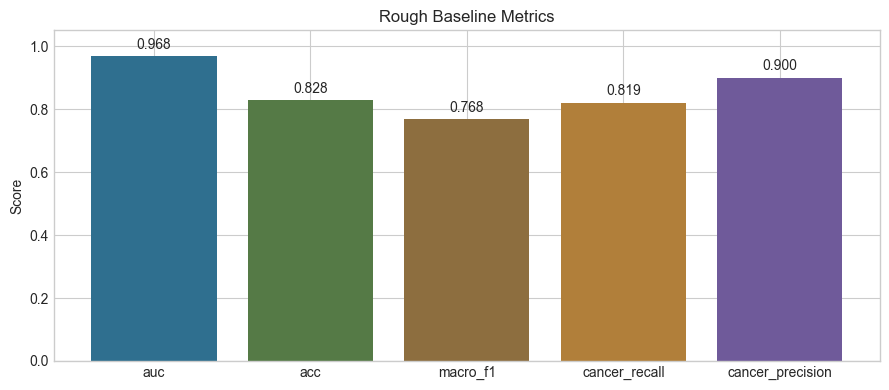

In [11]:
if baseline_metrics:
    metric_names = ['auc', 'acc', 'macro_f1', 'cancer_recall', 'cancer_precision']
    metric_values = [baseline_metrics[m] for m in metric_names]
    colors = ['#2f6f8f', '#557a46', '#8d6e3f', '#b17f3a', '#6f5a9a']
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(metric_names, metric_values, color=colors)
    ax.set_ylim(0, 1.05)
    ax.set_title('Rough Baseline Metrics')
    ax.set_ylabel('Score')
    for idx, value in enumerate(metric_values):
        ax.text(idx, value + 0.015, f'{value:.3f}', ha='center', va='bottom')
    plt.tight_layout()
    plt.show()

## 8. Does This Baseline Achieve The Website Benchmark?

Short answer: no. The rough baseline artifact loaded above does **not** achieve the website benchmark. It is useful for estimating baseline recall, but it should not be presented as a successful reproduction of the official ResNet-50 result.

Website target used here:

- AUC target: `0.990`
- ACC target: `0.911`

The final 4-model ensemble does beat these numbers, but that is an improved pipeline, not the simple baseline replication.

In [12]:
website_auc_target = 0.990
website_acc_target = 0.911

if baseline_metrics:
    benchmark_check = pd.DataFrame([{
        'run': baseline_name,
        'auc': baseline_metrics['auc'],
        'acc': baseline_metrics['acc'],
        'auc_target': website_auc_target,
        'acc_target': website_acc_target,
        'auc_delta': baseline_metrics['auc'] - website_auc_target,
        'acc_delta': baseline_metrics['acc'] - website_acc_target,
        'meets_auc_target': baseline_metrics['auc'] >= website_auc_target,
        'meets_acc_target': baseline_metrics['acc'] >= website_acc_target,
        'meets_both_targets': (
            baseline_metrics['auc'] >= website_auc_target
            and baseline_metrics['acc'] >= website_acc_target
        ),
    }])
    display(benchmark_check)
else:
    print('Cannot check benchmark target because baseline metrics are missing.')

,run,auc,acc,auc_target,acc_target,auc_delta,acc_delta,meets_auc_target,meets_acc_target,meets_both_targets
0,cifar_resnet18_official_seed31,0.967563,0.827994,0.99,0.911,-0.022437,-0.083006,False,False,False


### Baseline Versus Website Target Visualization

Both AUC and accuracy are below the website target for this rough baseline run.

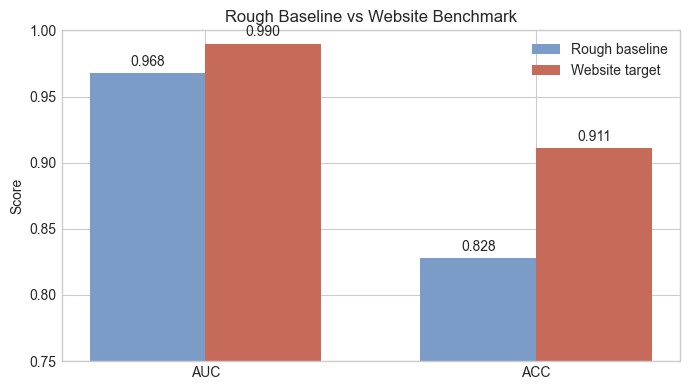

In [13]:
if baseline_metrics:
    compare_target = pd.DataFrame({
        'metric': ['AUC', 'ACC'],
        'rough_baseline': [baseline_metrics['auc'], baseline_metrics['acc']],
        'website_target': [website_auc_target, website_acc_target],
    })
    x = np.arange(len(compare_target))
    width = 0.35
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(x - width / 2, compare_target['rough_baseline'], width, label='Rough baseline', color='#7a9cc6')
    ax.bar(x + width / 2, compare_target['website_target'], width, label='Website target', color='#c66b5a')
    ax.set_xticks(x)
    ax.set_xticklabels(compare_target['metric'])
    ax.set_ylim(0.75, 1.0)
    ax.set_ylabel('Score')
    ax.set_title('Rough Baseline vs Website Benchmark')
    ax.legend()
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=3)
    plt.tight_layout()
    plt.show()

## 9. Per-Class Recall Baseline

This is the main reason for this notebook. We extract per-class recall from the classification report.

In [14]:
if baseline_metrics:
    report = baseline_metrics['classification_report']
    rows = []
    for class_name, metrics in report.items():
        if isinstance(metrics, dict) and 'recall' in metrics and class_name not in {'macro avg', 'weighted avg'}:
            rows.append({
                'class': class_name,
                'precision': metrics['precision'],
                'recall': metrics['recall'],
                'f1': metrics['f1-score'],
                'support': metrics['support'],
            })
    recall_df = pd.DataFrame(rows)
    display(recall_df.sort_values('recall'))

,class,precision,recall,f1,support
7,cancer-associated stroma,0.467568,0.410926,0.437421,421.0
5,smooth muscle,0.785276,0.432432,0.557734,592.0
2,debris,0.476471,0.716814,0.572438,339.0
4,mucus,0.968085,0.791304,0.870813,1035.0
8,colorectal adenocarcinoma epithelium,0.900178,0.819140,0.857749,1233.0
6,normal colon mucosa,0.791315,0.885290,0.835669,741.0
3,lymphocytes,0.888563,0.955836,0.920973,634.0
0,adipose,0.906314,0.997758,0.949840,1338.0
1,background,0.828767,1.000000,0.906367,847.0


### Per-Class Recall Visualization

A horizontal bar chart makes the weak classes immediately visible. The two cancer-related classes are highlighted.

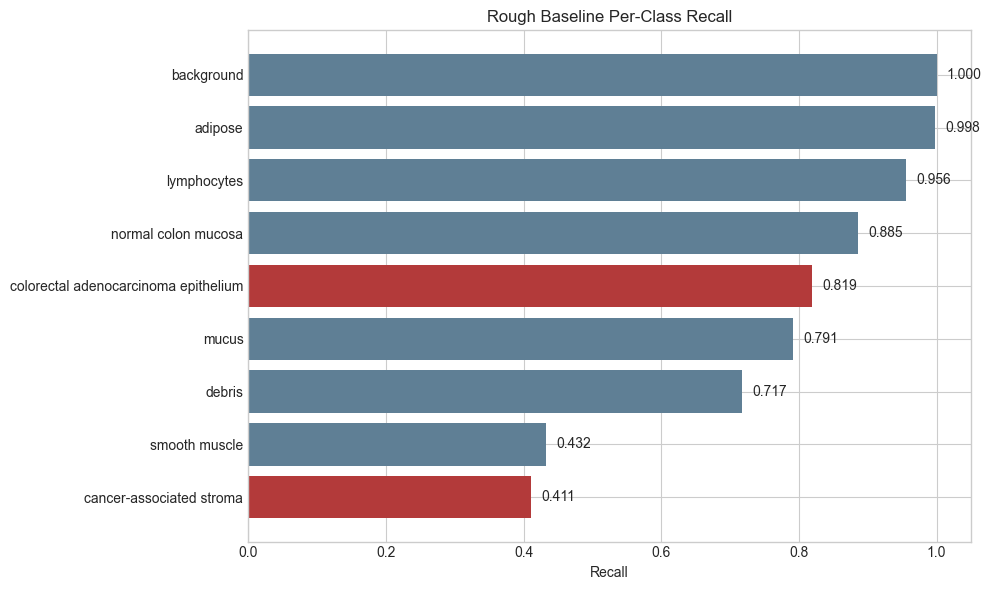

In [15]:
if baseline_metrics:
    recall_plot = recall_df.sort_values('recall', ascending=True).copy()
    cancer_related = {'cancer-associated stroma', 'colorectal adenocarcinoma epithelium'}
    colors = ['#b33a3a' if cls in cancer_related else '#5f7f95' for cls in recall_plot['class']]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(recall_plot['class'], recall_plot['recall'], color=colors)
    ax.set_xlim(0, 1.05)
    ax.set_xlabel('Recall')
    ax.set_title('Rough Baseline Per-Class Recall')
    for y, value in enumerate(recall_plot['recall']):
        ax.text(value + 0.015, y, f'{value:.3f}', va='center')
    plt.tight_layout()
    plt.show()

### Rough Baseline Recall Interpretation

From the available early-stopped official-style ResNet-18 baseline, the weakest recall classes were:

- cancer-associated stroma;
- smooth muscle;
- debris;
- colorectal adenocarcinoma epithelium was better than stroma but still not ideal.

This matches the later improvement work: the hard part was not background or adipose, but separating histologically similar classes under test-center shift.

## 10. Confusion Matrix

The confusion matrix helps explain where recall is lost. Rows are true classes, columns are predicted classes.

In [16]:
class_names = CLASS_NAMES

if baseline_metrics:
    cm = pd.DataFrame(baseline_metrics['confusion_matrix'], index=class_names, columns=class_names)
    display(cm)

,adipose,background,debris,lymphocytes,mucus,smooth muscle,normal colon mucosa,cancer-associated stroma,colorectal adenocarcinoma epithelium
adipose,1335,0,0,0,0,2,0,1,0
background,0,847,0,0,0,0,0,0,0
debris,0,9,243,0,0,23,0,58,6
lymphocytes,0,0,22,606,0,0,1,0,5
mucus,104,105,1,0,819,0,5,1,0
smooth muscle,7,55,133,0,1,256,0,124,16
normal colon mucosa,21,0,1,35,8,1,656,10,9
cancer-associated stroma,0,6,106,6,4,44,6,173,76
colorectal adenocarcinoma epithelium,6,0,4,35,14,0,161,3,1010


### Confusion Matrix Heatmaps

The raw-count heatmap shows where mistakes occur. The row-normalized heatmap is more directly connected to recall because each row sums to 1.

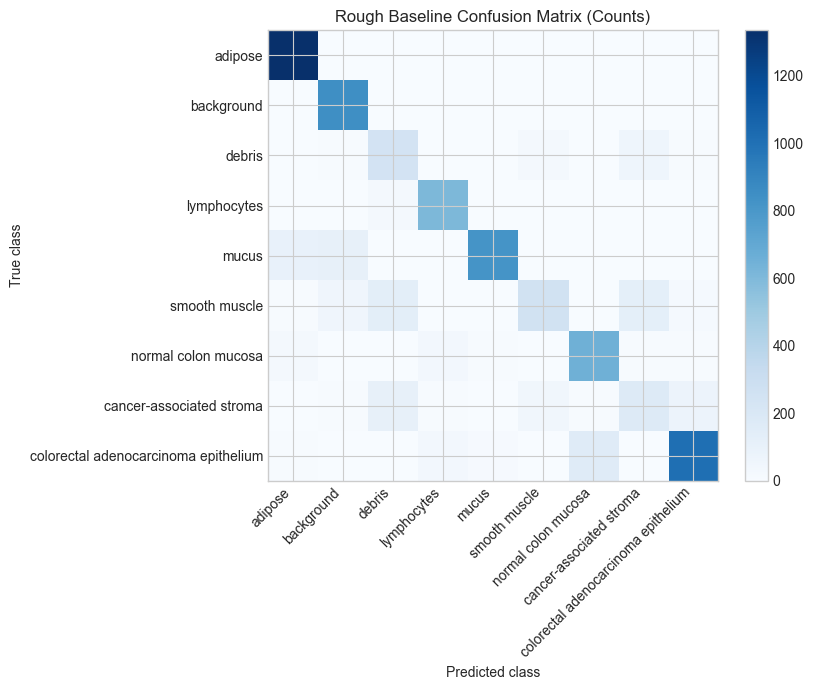

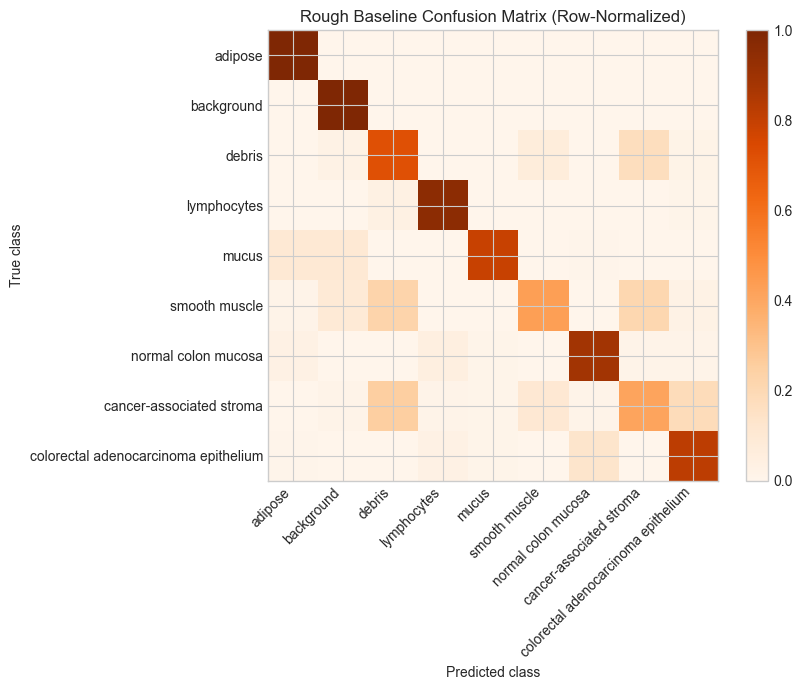

In [17]:
if baseline_metrics:
    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(cm.values, cmap='Blues')
    ax.set_title('Rough Baseline Confusion Matrix (Counts)')
    ax.set_xlabel('Predicted class')
    ax.set_ylabel('True class')
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticklabels(class_names)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

    cm_norm = cm.div(cm.sum(axis=1), axis=0)
    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(cm_norm.values, cmap='Oranges', vmin=0, vmax=1)
    ax.set_title('Rough Baseline Confusion Matrix (Row-Normalized)')
    ax.set_xlabel('Predicted class')
    ax.set_ylabel('True class')
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticklabels(class_names)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

## 11. Compare Rough Baseline To Final Improved Result

This is not the main goal of the notebook, but it gives context for why recall diagnostics matter.

In [18]:
final_ensemble_path = RESULTS / 'ensemble_4model_metrics.json'
final_ensemble = json.loads(final_ensemble_path.read_text()) if final_ensemble_path.exists() else None

rows = []
if baseline_metrics:
    rows.append({
        'run': 'rough official-style baseline',
        'auc': baseline_metrics['auc'],
        'acc': baseline_metrics['acc'],
        'macro_f1': baseline_metrics['macro_f1'],
        'cancer_recall': baseline_metrics['cancer_recall'],
        'cancer_precision': baseline_metrics['cancer_precision'],
    })
if final_ensemble:
    rows.append({
        'run': '4-model soft-voting ensemble',
        'auc': final_ensemble['auc'],
        'acc': final_ensemble['acc'],
        'macro_f1': final_ensemble['macro_f1'],
        'cancer_recall': final_ensemble['cancer_recall'],
        'cancer_precision': final_ensemble['cancer_precision'],
    })

if rows:
    display(pd.DataFrame(rows))

,run,auc,acc,macro_f1,cancer_recall,cancer_precision
0,rough official-style baseline,0.967563,0.827994,0.767667,0.819140,0.900178
1,4-model soft-voting ensemble,0.991565,0.925627,0.893340,0.961882,0.920807


### Baseline Versus Improved Ensemble Visualization

This grouped bar chart shows how the final ensemble changes the main metrics compared with the rough baseline.

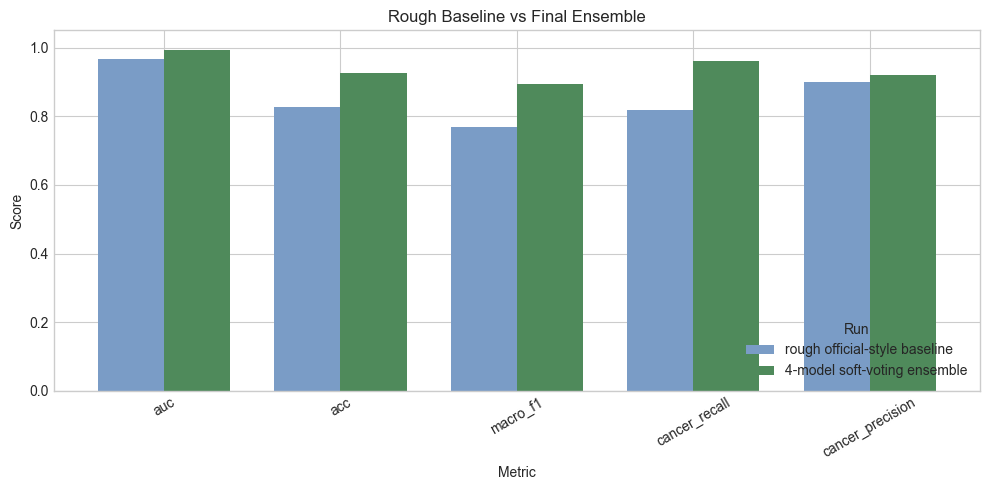

In [19]:
if rows:
    comparison_df = pd.DataFrame(rows).set_index('run')
    metric_cols = ['auc', 'acc', 'macro_f1', 'cancer_recall', 'cancer_precision']
    ax = comparison_df[metric_cols].T.plot(kind='bar', figsize=(10, 5), width=0.75, color=['#7a9cc6', '#4f8a5b'])
    ax.set_ylim(0, 1.05)
    ax.set_title('Rough Baseline vs Final Ensemble')
    ax.set_ylabel('Score')
    ax.set_xlabel('Metric')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Run', loc='lower right')
    plt.tight_layout()
    plt.show()

## 12. Optional: Recompute Recall From Prediction Files

The metrics JSON already contains recall, but we can recompute it from saved prediction probabilities to verify the calculation.

In [20]:
from sklearn.metrics import classification_report, recall_score

pred_path = RESULTS / 'experiments' / baseline_name / 'test_predictions_eval.npz'

if pred_path.exists():
    pred = np.load(pred_path)
    y_true = pred['y_true'].reshape(-1)
    y_pred = pred['y_prob'].argmax(axis=1)
    print('Macro recall:', recall_score(y_true, y_pred, average='macro'))
    print('Cancer class recall:', recall_score(y_true == 8, y_pred == 8))
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
else:
    print('Prediction file not found:', pred_path)

Macro recall: 0.7788335079627187
Cancer class recall: 0.819140308191403
                                      precision    recall  f1-score   support

                             adipose       0.91      1.00      0.95      1338
                          background       0.83      1.00      0.91       847
                              debris       0.48      0.72      0.57       339
                         lymphocytes       0.89      0.96      0.92       634
                               mucus       0.97      0.79      0.87      1035
                       smooth muscle       0.79      0.43      0.56       592
                 normal colon mucosa       0.79      0.89      0.84       741
            cancer-associated stroma       0.47      0.41      0.44       421
colorectal adenocarcinoma epithelium       0.90      0.82      0.86      1233

                            accuracy                           0.83      7180
                           macro avg       0.78      0.78      0.77 

## 13. Conclusions

The rough benchmark-style baseline recall estimate shows why accuracy alone is insufficient:

- some easy classes have near-perfect recall;
- clinically relevant or histologically similar classes are much harder;
- cancer-associated stroma is the most persistent weakness;
- adenocarcinoma recall is useful to track separately from total accuracy.

For the report, the baseline recall should be presented as an estimated local baseline unless a full ResNet-50 benchmark reproduction is run to convergence. The exact command for that fuller reproduction is included above.